In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
# Create data
import numpy as np
import os
from os.path import join
import matplotlib.pyplot as plt
from itertools import product
from utils.save_load import load
def find_level(s):
    for level in ['high', 'medium', 'low']:
        if level in s:
            return level
            
def load_client_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_client_acc.pt"))

def load_client_size(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "list_model_size.pt"))

def load_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))


def load_acc(exp, cs=False):
    c = load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_acc.pt"))
    if c[0] == 0:
        return c[1:]
    else:
        return c

def load_real_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "time.pt"))

def load_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.time"))

def load_ms(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_size.pt"))

def load_fed_avg_acc(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_acc.pt"))

def load_best_acc(exp, cs=False):
    acc = np.asarray(load_acc(exp, cs=cs), dtype=float)
    fed_avg_acc = np.asarray(load_fed_avg_acc(exp, cs=cs), dtype=float)
    min_len = min(len(acc), len(fed_avg_acc))
    if min_len == 0:
        return np.asarray([], dtype=float)
    return np.maximum(acc[:min_len], fed_avg_acc[:min_len])

def load_fed_avg_loss(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "fed_avg_loss.pt"))

def load_model_G(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "model_G.pt"))

def load_list_client_time(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_time.pt"))

def load_list_client_density(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.list_client_density"))
    
def load_train_number(exp, cs=False):
    return load(join(result_path, "{}{}".format(exp, "_cs" if cs else ""), "self.train_number"))


def use_virtual_time_for_sync_mhfl(exp_name):
    exp_name = exp_name.lower()
    is_mhfl = any(name in exp_name for name in ['fjord', 'heterofl', 'fedrolex'])
    if not is_mhfl:
        return False
    enhanced_tags = ['gmr', 'abgmr', 'ims', 'asyn']
    return not any(tag in exp_name for tag in enhanced_tags)

def load_virtual_time_for_sync_mhfl(exp_name, cs=False):
    candidates = []
    if 'heterofl' in exp_name.lower():
        candidates.append(exp_name + 'get_time')
    level = find_level(exp_name)
    if level is not None:
        candidates.append('Time_' + level)
    for candidate in candidates:
        time_path = join(result_path, "{}{}".format(candidate, "_cs" if cs else ""), "self.time")
        if os.path.exists(time_path):
            return load(time_path)
    raise FileNotFoundError(f"No virtual time found for {exp_name}")

def get_static_avg_density(exp_name):
    exp_name = exp_name.lower()
    density_map = {
        'high': [1.0, 0.5, 0.2, 0.1] + [0.05] * 6,
        'medium': [1.0, 0.5] + [0.2] * 2 + [0.1] * 3 + [0.05] * 3,
        'low': [1.0] * 2 + [0.5] * 2 + [0.2] * 2 + [0.1] * 2 + [0.05] * 2,
    }
    for level, densities in density_map.items():
        if level in exp_name:
            return float(np.mean(np.asarray(densities, dtype=float)))
    return float(np.mean(np.asarray(density_map['high'], dtype=float)))

def get_acc_time(acc,time):
    target_acc = [0.83]
    n = 20
    cv_acc = np.convolve(acc, np.ones((n,)) / n, mode='valid')
    cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
        # 创建一个字典来存储每个阈值的第一次超过的索引
    exceedances = {threshold: None for threshold in target_acc}
    ac_time = [None]*3
    i = 0
    # 遍历序列，检查每个元素是否超过任何未标记的阈值
    for index, value in enumerate(cv_acc):
        for threshold in target_acc:
            # 如果当前值大于阈值，并且这个阈值还没有找到超过的位置
            if value > threshold and exceedances[threshold] is None:
                exceedances[threshold] = int(cv_time[index])
                ac_time[i] = int(cv_time[index])
                i = i+1
    return ac_time



# 自定义格式化函数，将 x 轴单位改为 10^3
def format_kilo(x, _):
    return f"{int(x / 10000)}"
def plt_photo_acc(exp, exp_legend, fig_name='PR-FL', y_lim=[0.70, 0.90], x_lim=[1, 80000], cov = False):
    import matplotlib.pyplot as plt
    import os
    from os.path import join
    
    # Define the interval for markers
    interval = 50  # You can adjust this value to change the marker density
    # config2 = type("Config", (object,), {"EXP_NAME": "experiment_name"})  # 示例配置
    

    # Create a new figure
    figsize = (7, 5.25)
    plt.figure(figsize=figsize)
    ac_time = {}
    time = None
    from matplotlib.ticker import FuncFormatter
    # Iterate through all experiments to plot each curve
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_best_acc(exp_name)
            if use_virtual_time_for_sync_mhfl(exp_name):
                time = load_virtual_time_for_sync_mhfl(exp_name)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
                
            cv_acc = np.convolve(fed_avg_acc, np.ones((n,)) / n, mode='valid')
            cv_time = np.convolve(time, np.ones((n,)) / n, mode='valid')
            if not cov: 
                cv_acc = fed_avg_acc
                cv_time = time
            # if 'fed_avg' in exp_name and 'mask_fed_avg' not in exp_name:
            #    interval = int(interval / 2)
            plt.plot(cv_time, cv_acc, linestyle=linestyles[i ], color=colors[i], linewidth=1, label=exp_legend[i],marker=markers[i],markevery=interval)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    # for key in ac_time.keys():
    #     print(key, ":", ac_time[key])
    # Set labels and axis limits
    plt.xlabel("Time ($10^4$ s)",fontsize=16)
    plt.ylabel("Test Accuracy",fontsize=16)
    plt.xticks(fontsize=14)  # 增大 x 轴刻度字体
    plt.yticks(fontsize=14)  # 增大 y 轴刻度字体
    plt.xlim(x_lim)
    plt.ylim(y_lim)
    # 使用 FuncFormatter 应用自定义格式
    plt.gca().xaxis.set_major_formatter(FuncFormatter(format_kilo))
    # Add legend
    # Add legend
    plt.legend(
        frameon=False,
        loc="lower right",
        bbox_to_anchor=(1, 0),
        fontsize= 'x-large',
        ncol=2
    )

    # Set grid
    plt.grid(linestyle="--", color='black', lw=0.5, alpha=0.5)

    # Ensure result directories exist and save the figure
    result_path = join("results", config.EXP_NAME)
    fig_path = join(result_path, "figs")

    if not os.path.isdir(fig_path):
        os.makedirs(fig_path)

    plt.savefig(join(fig_path, fig_name + ".png"), dpi=600, bbox_inches='tight')  # Save as PNG format
    plt.show()

def get_time_acc(acc,time,time_line):
    windows = 10
    for index, T in enumerate(time):
        if T>time_line :
            break;
    import numpy as np
    # index = int(10000/25)


    b_mean = np.mean(acc[index-windows:index+windows])*100
    b_std = np.std(acc[index-windows:index+windows])*100

    return [time_line,round(b_mean, 2),f"{b_std:.2g}"]

def plt_time_acc(exp, time_line, acc_type='avg'):
    time_acc = {}
    for i in range(len(exp)):
        exp_name = exp[i]
        try:
            # Load data
            fed_avg_acc = load_fed_avg_acc(exp_name)
            acc = load_acc(exp_name)
            
            # if  np.mean(acc[-100:-1])>np.mean(fed_avg_acc[-100:-1]):
            #     fed_avg_acc = acc
            # else:
            #     fed_avg_acc = fed_avg_acc
            fed_avg_acc = np.maximum(fed_avg_acc, acc)
            if use_virtual_time_for_sync_mhfl(exp_name):
                time = load_virtual_time_for_sync_mhfl(exp_name)
                min_len = min(len(time), len(fed_avg_acc))
                fed_avg_acc = fed_avg_acc[:min_len]
                time = time[:min_len]
            else:
                time = load_time(exp_name)
            time_acc[exp_name] = get_time_acc(fed_avg_acc,time,time_line)
        except FileNotFoundError:
            print(f"Skipping {exp_name}. Client selection = {client_sel}.")
    import pandas as pd
    import os
    from openpyxl import load_workbook
    for k, v in time_acc.items():
        print(k,v)
    file_path = config.EXP_NAME+'.xlsx'
    sheet_name = 'Sheet1'
    
    # 构造你的数据（你已有的 time_acc）
    df_new = pd.DataFrame([
        {
            'Name': k,
            'Time': v[0],
            'Accuracy': v[1],
            'Std': float(v[2]) if isinstance(v[2], str) else v[2]
        }
        for k, v in time_acc.items()
    ])
    
    # 如果文件存在，读取旧数据；否则创建空DataFrame
    if os.path.exists(file_path):
        df_old = pd.read_excel(file_path, sheet_name=sheet_name)
        df_combined = pd.concat([df_old, df_new], ignore_index=True)
    
        # 以追加模式打开并替换已有 sheet
        with pd.ExcelWriter(file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            df_combined.to_excel(writer, sheet_name=sheet_name, index=False)
    else:
        # 如果文件不存在，直接写入新数据
        df_new.to_excel(file_path, index=False)

        
dataset_name = "CIFAR10"
import configs.cifar10 as config
client_sel = False
time_lim = (-1000, 60000)
acc_lim = (0.0, 0.9)
lottery_ticket_acc_lim = (0.7, 0.9)
n = 20

result_path = join("results", config.EXP_NAME)
if not os.path.isdir(f"results/{config.EXP_NAME}/figs"):
    os.makedirs(f"results/{config.EXP_NAME}/figs")
fig_path = join(result_path, "figs")
linestyles = [(0, (2, 2)),'-', '--', '-.', ':', (0, (5, 1)), (0, (3, 5, 1, 5)), ]
colors     = ['red','blue', 'green', 'purple', 'orange', 'brown', 'pink']  # 第7个 red = 你的方法
markers    = [ '^','o', '*', 'D', 's', 'p', 'v',]  # 第7个 '^' = 你的方法


In [2]:
import os
result_path = join("results", config.EXP_NAME)
list = os.listdir(result_path)
list = sorted(list)
filtered = [x for x in list if any(key in x.lower() for key in ["ims", "pure", "buff"])]
filtered

['Ablation_iid_high_buff',
 'Ablation_iid_high_ims',
 'Ablation_iid_high_pure',
 'Ablation_iid_high_pure2',
 'Ablation_iid_low_buff',
 'Ablation_iid_low_ims',
 'Ablation_iid_low_pure',
 'Ablation_iid_low_pure2',
 'Ablation_iid_medium_buff',
 'Ablation_iid_medium_ims',
 'Ablation_iid_medium_pure',
 'Ablation_iid_medium_pure2',
 'Ablation_niid_25_2.0_lowbuff',
 'Ablation_niid_25_low_buff',
 'Ablation_niid_high_buff',
 'Ablation_niid_high_ims',
 'Ablation_niid_high_pure',
 'Ablation_niid_high_pure2',
 'Ablation_niid_low_buff',
 'Ablation_niid_low_ims',
 'Ablation_niid_low_pure',
 'Ablation_niid_low_pure2',
 'Ablation_niid_medium_buff',
 'Ablation_niid_medium_ims',
 'Ablation_niid_medium_pure',
 'Ablation_niid_medium_pure2',
 'iid_2.0_high_10_buff_Cifar10',
 'iid_2.0_high_10_ims_Cifar10',
 'iid_2.0_high_10_pure2_Cifar10',
 'iid_2.0_high_10_pure_Cifar10',
 'iid_2.0_low_10_buff_Cifar10',
 'iid_2.0_low_10_ims_Cifar10',
 'iid_2.0_low_10_pure2_Cifar10',
 'iid_2.0_low_10_pure_Cifar10',
 'iid_2.0

In [3]:
import re
import numpy as np
from dataclasses import dataclass
from typing import List, Optional

RE_ROUND   = re.compile(r"Round\s*#(\d+)")
RE_ELAPSED = re.compile(r"Elapsed time\s*=\s*([+-]?\d+(?:\.\d+)?)")

# 兼容：loss/acc (at round #500) = loss1/acc1   Loss/acc=loss2/acc2
RE_ACC2 = re.compile(
    r"fed_avg\s+Loss/acc.*?=\s*([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)/([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)"
    r".*?Loss/acc\s*=\s*([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)/([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)",
    re.IGNORECASE,
)

RE_DENSITY = re.compile(r"(?:the\s+)?density is\s*([0-9eE\+\-\.,\s]+)", re.IGNORECASE)

@dataclass
class RoundRecord:
    round: int
    elapsed_time: Optional[float] = None
    best_acc: Optional[float] = None
    densities: Optional[List[float]] = None
    avg_density: Optional[float] = None

def parse_log_file(log_path: str) -> List[RoundRecord]:
    records: List[RoundRecord] = []
    cur: Optional[RoundRecord] = None

    def commit_if_useful(r: Optional[RoundRecord]):
        if r is None:
            return
        # 这一轮至少有一个关键字段才保存
        if (r.elapsed_time is not None) or (r.best_acc is not None) or (r.densities is not None):
            records.append(r)
    log_path = join(result_path,"{}{}".format(log_path, ""), "app.log")
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            # 1) Round 开始
            m = RE_ROUND.search(line)
            if m:
                commit_if_useful(cur)
                cur = RoundRecord(round=int(m.group(1)))
                continue

            if cur is None:
                continue  # 没遇到 round 之前都不要

            # 2) elapsed time
            m = RE_ELAPSED.search(line)
            if m:
                cur.elapsed_time = float(m.group(1))
                continue

            # 3) best acc
            m = RE_ACC2.search(line)
            if m:
                acc1 = float(m.group(2))
                acc2 = float(m.group(4))
                cur.best_acc = max(acc1, acc2)
                continue

            # 4) density list + avg
            m = RE_DENSITY.search(line)
            if m:
                raw = m.group(1).strip()
                nums = [x for x in re.split(r"[,\s]+", raw) if x]
                dens = [float(x) for x in nums]
                cur.densities = dens
                cur.avg_density = float(np.mean(dens)) if dens else None
                continue

            # 其它任何行：直接丢弃（什么都不做）

    commit_if_useful(cur)
    return records
    
import numpy as np
import matplotlib.pyplot as plt

# 从 records 直接抽出 time / acc / avg_density
def extract_time_acc_density(records, require_time=True):
    t, acc, den = [], [], []
    for r in records:
        if r.best_acc is None:
            continue
        if require_time and r.elapsed_time is None:
            continue

        if r.elapsed_time is not None:
            t.append(float(r.elapsed_time))
        acc.append(float(r.best_acc))

        if r.avg_density is not None:
            den.append(float(r.avg_density))
        elif r.densities is not None and len(r.densities) > 0:
            den.append(float(np.mean(np.asarray(r.densities, dtype=float))))
        else:
            den.append(np.nan)

    if require_time:
        t = np.asarray(t, dtype=float)
    else:
        t = np.arange(len(acc), dtype=float)
    acc = np.asarray(acc, dtype=float)
    den = np.asarray(den, dtype=float)

    # 只去掉 NaN（不排序、不断线）
    m = np.isfinite(acc)
    if require_time:
        m = m & np.isfinite(t)
    return t[m], acc[m], den[m]


# 画你想要的双轴图：Acc(左) + Density(右)，每个实验同色两条线
def plot_dual_axis_from_logs(exp_list, exp_labels, xlim=(0, 240000),
                             acc_ylim=(0.2, 0.9), den_ylim=(0, 1.1),
                             out_path="CIFAR_dual_axis_comparison.png"):

    plt.rcParams.update({
        "font.size": 24,
        "axes.titlesize": 26,
        "axes.labelsize": 26,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18
    })

    fig, ax1 = plt.subplots(figsize=(12, 7))
    ax2 = ax1.twinx()

    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    lines, labels = [], []

    for i, exp in enumerate(exp_list):
        color = colors[i % len(colors)]

        records = parse_log_file(exp)  # exp = log path
        if use_virtual_time_for_sync_mhfl(exp):
            acc = np.asarray(load_best_acc(exp), dtype=float)
            virtual_time = np.asarray(load_virtual_time_for_sync_mhfl(exp), dtype=float)
            min_len = min(len(virtual_time), len(acc))
            t = virtual_time[:min_len]
            acc = acc[:min_len]
            avg_den = np.full(min_len, get_static_avg_density(exp), dtype=float)
        else:
            t, acc, avg_den = extract_time_acc_density(records)

        # Acc：左轴，实线
        l1, = ax1.plot(t, acc, color=color, linestyle='-', linewidth=2,
                       label=f"{exp_labels[i]} (Acc)")
        lines.append(l1); labels.append(f"{exp_labels[i]} (Acc)")

        # Density：右轴，按你原来三种风格
        if i == 0:
            l2, = ax2.plot(t, avg_den, color=color, linestyle='--',
                           marker='o', markersize=4,
                           label=f"{exp_labels[i]} (Density)")
        elif i == 1:
            l2, = ax2.plot(t, avg_den, color=color, linestyle='--',
                           linewidth=2,
                           label=f"{exp_labels[i]} (Density)")
        else:
            l2, = ax2.plot(t, avg_den, color=color, linestyle='-.',
                           linewidth=2,
                           label=f"{exp_labels[i]} (Density)")

        lines.append(l2); labels.append(f"{exp_labels[i]} (Density)")

    # 左轴
    # ax1.set_xlabel("(b) CIFAR-10", fontsize=24)
    # ax1.set_ylabel("Test Accuracy", fontsize=20, fontweight='bold')
    ax1.set_ylim(*acc_ylim)

    # 右轴
    # ax2.set_ylabel("Average Model Density", fontsize=16, fontweight='bold',
    #                rotation=270, labelpad=15)
    ax2.set_ylim(*den_ylim)

    # ax1.set_title("Comparison: Accuracy & Density over Time", fontsize=20)

    ax1.legend(lines, labels, loc='lower right', ncol=1, fontsize=24, frameon=True)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_xlim(*xlim)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()



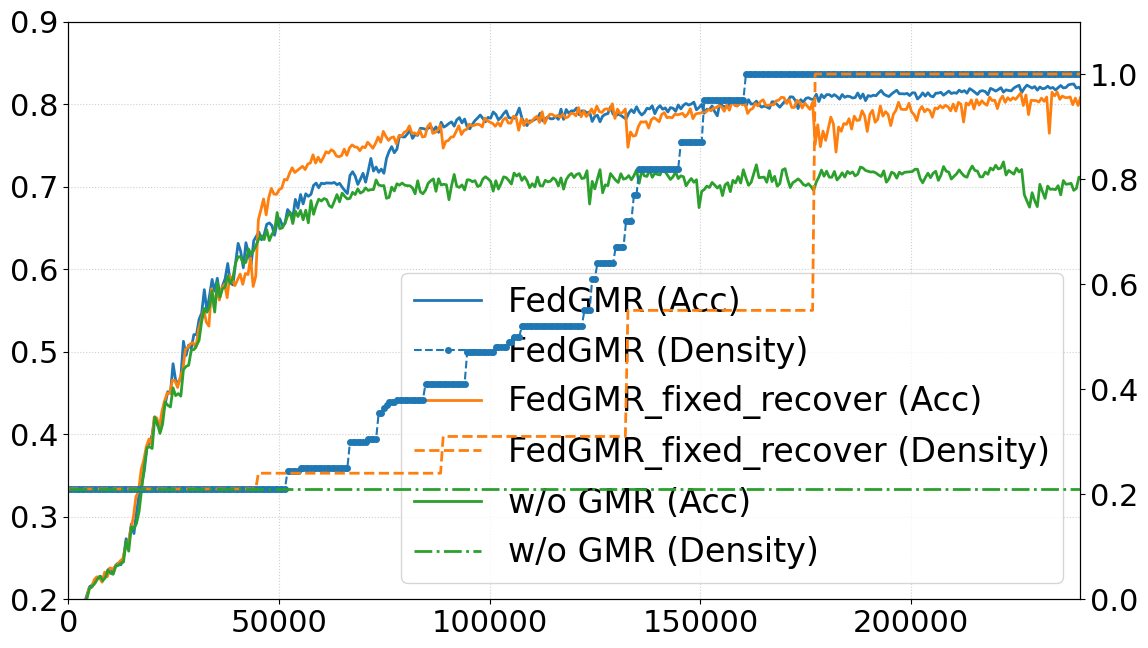

niid_2.0_high_pr_fl_FEMNIST_15 [220000, 81.68, '0.28']
niid_2.0_high_pr_fl_Cifar10_7_rtm_time_rtt_220000 [220000, 80.42, '0.48']
Ablation_niid_high_gmr [220000, 71.93, '0.45']


In [4]:


exp_list =[

 'niid_2.0_high_pr_fl_FEMNIST_15',
'niid_2.0_high_pr_fl_Cifar10_7_rtm_time_rtt_220000',

# 'Ablation_niid_high_asyn', 
'Ablation_niid_high_gmr',

]

exp_labels = [
    'FedGMR',
    'FedGMR_fixed_recover',
    # 'w/o Asyn',
    'w/o GMR',
]
plot_dual_axis_from_logs(exp_list, exp_labels, out_path="CIFAR10_fixed_comparison.png")

plt_time_acc(exp_list, 220000)






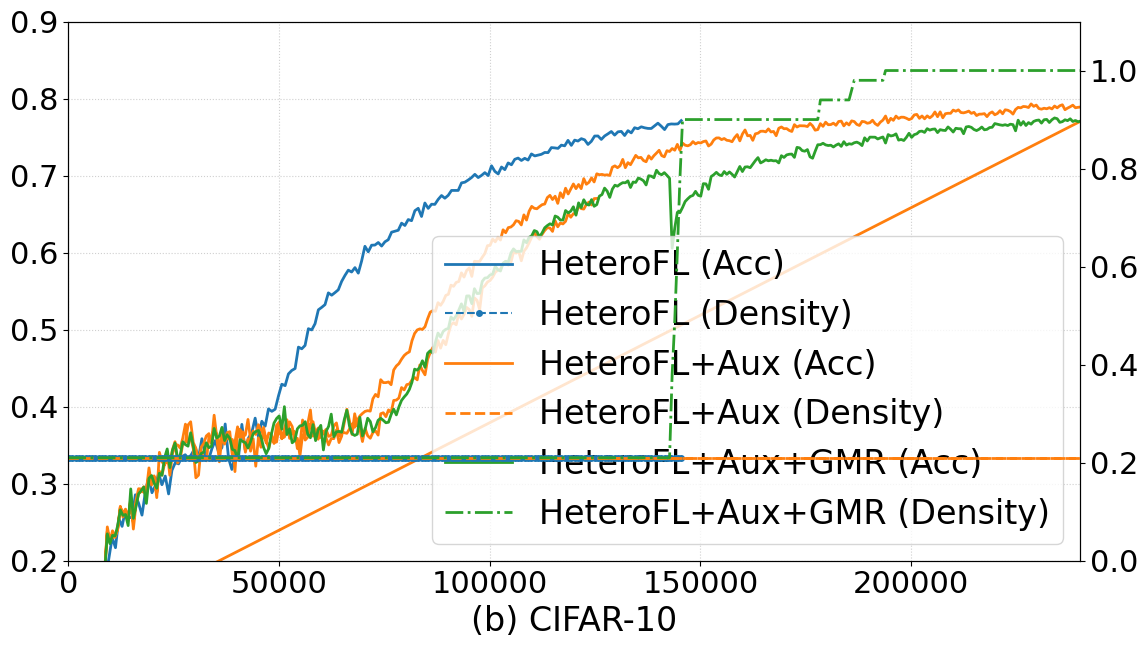

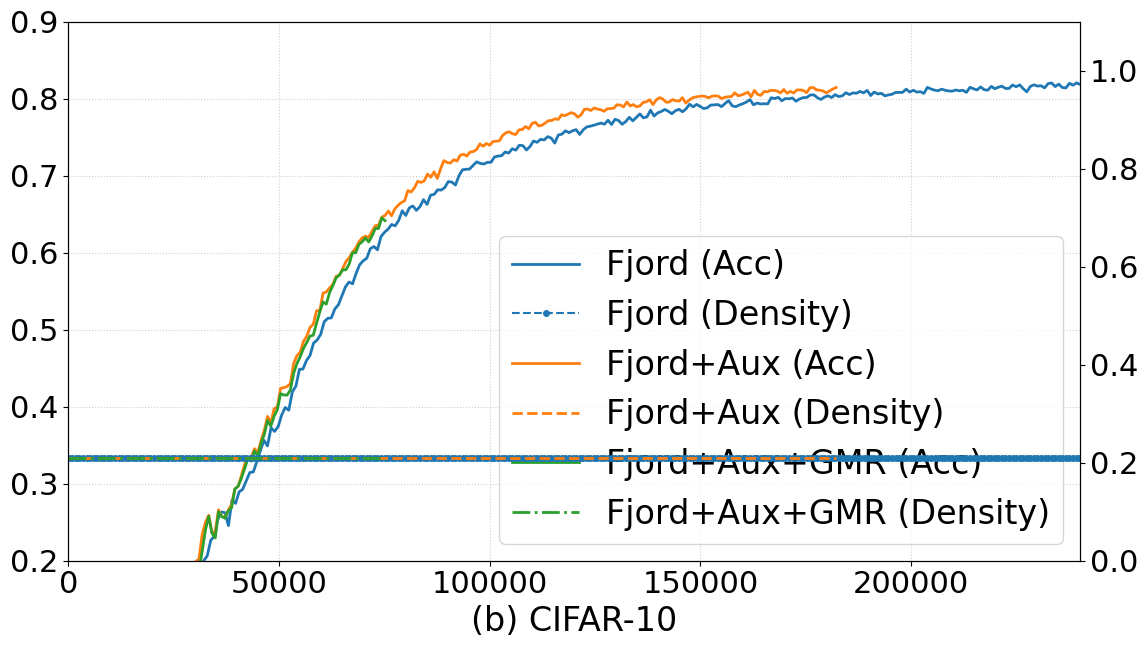

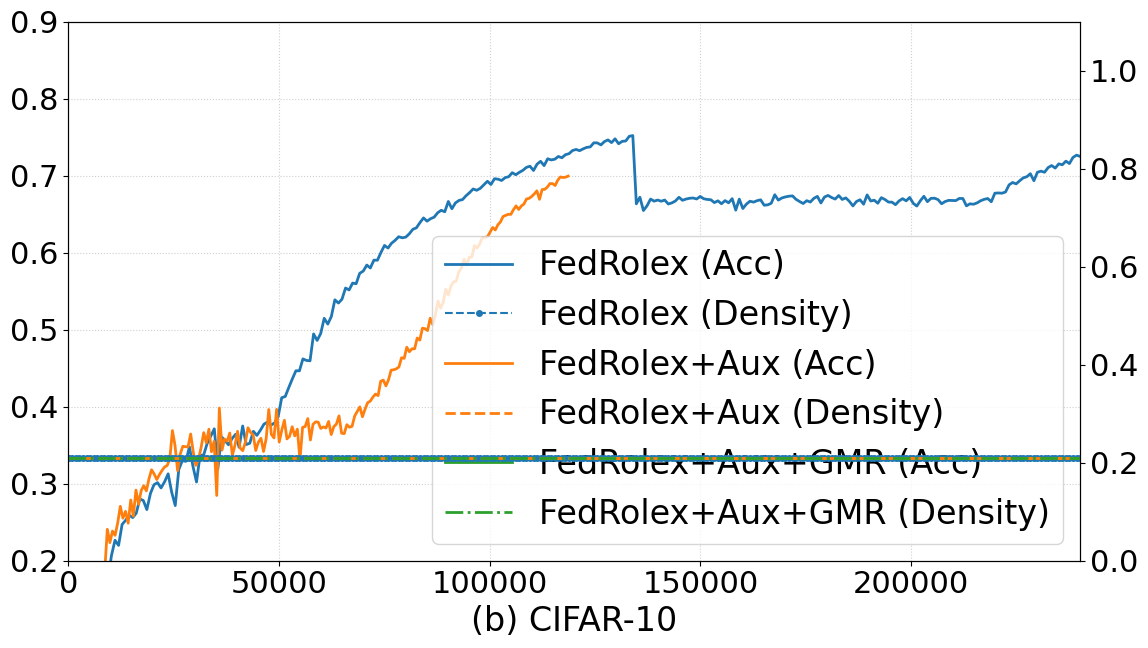

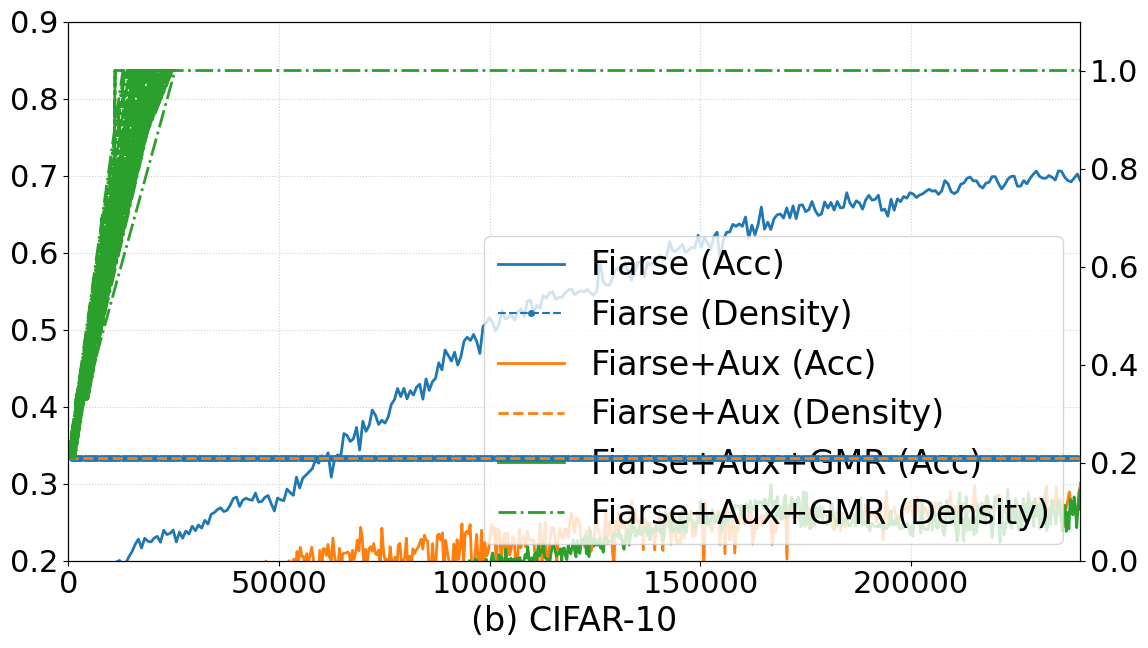

In [46]:


exp_list_2 =[

 'niid_high_heterofl_Cifar10',
'niid_high_abgmr_heterofl_Cifar10', 
'niid_high_gmr_heterofl_Cifar10',


]


exp_labels_2 = ['HeteroFL',  'HeteroFL+Aux',  'HeteroFL+Aux+GMR']
plot_dual_axis_from_logs(exp_list_2, exp_labels_2, out_path="Cifar10_heterofl_comparison.png")


exp_list_3 =[

 'niid_high_fjord_Cifar10',
        'niid_high_abgmr_fjord_Cifar10',
        'niid_high_gmr_fjord_Cifar10_25',



]


exp_labels_3 = ['Fjord',  'Fjord+Aux',  'Fjord+Aux+GMR']
plot_dual_axis_from_logs(exp_list_3, exp_labels_3, out_path="Cifar10_Fjord_comparison.png")



exp_list_4 =[

 'niid_high_fedrolex_Cifar10NBP',
    'niid_high_abgmr_fedrolex_Cifar10',
        'niid_high_gmr_fedrolex_Cifar10',
]


exp_labels_4 = ['FedRolex',  'FedRolex+Aux',  'FedRolex+Aux+GMR',]
plot_dual_axis_from_logs(exp_list_4, exp_labels_4, out_path="Cifar10_FedRolex_comparison.png")



exp_list_5 =[

 'niid_2.0_high_fiarse_FEMNIST_w',
        'niid_25_2.0_high_abgmr_fiarse_Cifar10_w',
    'niid_25_2.0_high_gmr_fiarse_Cifar10_w',

]


exp_labels_5 = ['Fiarse',  'Fiarse+Aux',  'Fiarse+Aux+GMR',]
plot_dual_axis_from_logs(exp_list_5, exp_labels_5, out_path="Cifar10_Fiarse_comparison.png")


    
    
    
    

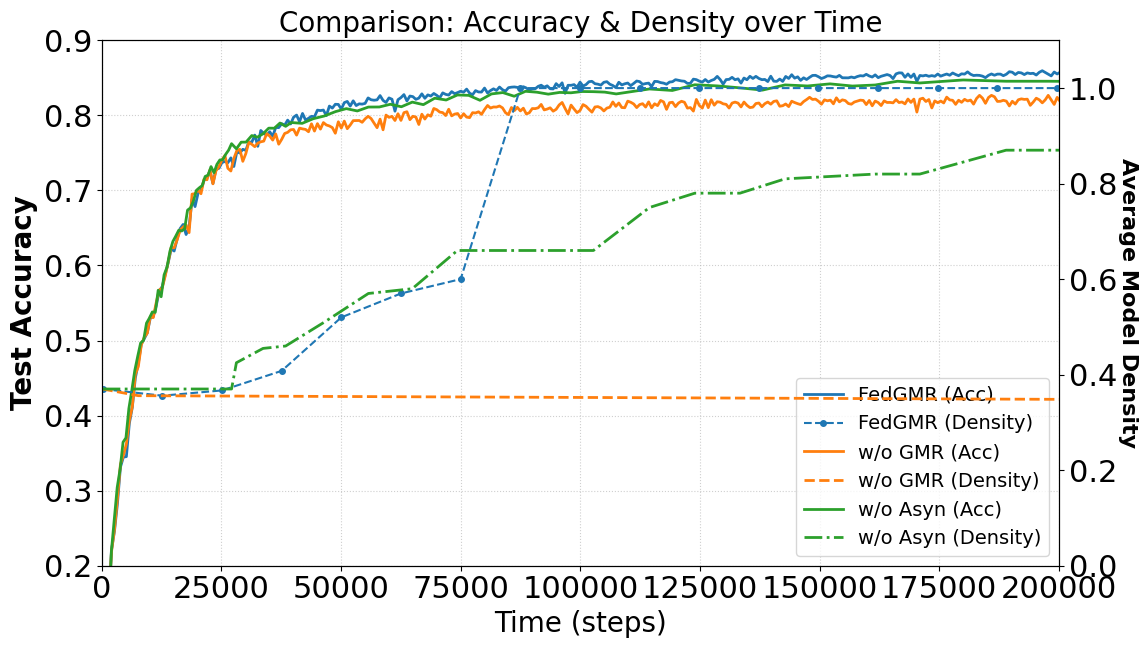

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------------------------
# 1. 数据准备 (Data Preparation)
# -----------------------------------------------------------------------------

raw1 = """
159	[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
12625	[1001, 988, 1001, 1001, 1000, 1001, 1000, 1000, 995, 984]	1.00,0.88,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.05
25103	[2001, 1885, 2001, 2001, 1999, 2001, 1999, 2000, 1988, 1977]	1.00,1.00,0.49,0.49,0.19,0.20,0.10,0.10,0.05,0.05
37594	[3001, 2969, 3001, 3001, 2997, 2820, 2998, 2823, 2981, 2963]	1.00,1.00,0.49,0.49,0.20,0.50,0.10,0.20,0.05,0.05
50051	[4001, 3782, 3750, 3526, 3996, 3200, 3998, 3314, 3449, 3597]	1.00,1.00,1.00,1.00,0.20,0.50,0.10,0.20,0.10,0.10
62510	[5001, 4602, 4250, 4026, 4460, 3573, 4617, 3804, 3874, 3857]	1.00,1.00,1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.20
74984	[6001, 5421, 4750, 4526, 4829, 3938, 5101, 4227, 4306, 4107]	1.00,1.00,1.00,1.00,0.50,0.50,0.20,0.50,0.10,0.20
87462	[7001, 6237, 5248, 5026, 5099, 4236, 5352, 4401, 4450, 4242]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
99930	[8001, 7036, 5745, 5524, 5318, 4457, 5471, 4519, 4514, 4306]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
112388	[9001, 7844, 6239, 6021, 5536, 4676, 5589, 4638, 4579, 4371]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
124861	[10001, 8655, 6736, 6521, 5755, 4895, 5707, 4757, 4643, 4436]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
137304	[11001, 9465, 7233, 7018, 5973, 5115, 5825, 4874, 4707, 4501]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
149755	[12001, 10274, 7729, 7516, 6191, 5332, 5943, 4993, 4772, 4565]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
162235	[13001, 11091, 8226, 8014, 6411, 5555, 6062, 5111, 4836, 4630]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
174679	[14001, 11902, 8723, 8508, 6629, 5773, 6179, 5229, 4901, 4694]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
187142	[15001, 12715, 9220, 9004, 6848, 5992, 6297, 5348, 4965, 4759]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
199625	[16001, 13516, 9718, 9498, 7067, 6213, 6415, 5465, 5030, 4823]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
""".strip()



raw2 = """
159	[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
7631 [601, 589, 601, 601, 600, 601, 600, 600, 597, 593] 1.00,0.88,0.50,0.49,0.19,0.20,0.10,0.10,0.05,0.05
309283 [24801, 24784, 24799, 24800, 24799, 24799, 24792, 24790, 24570, 24535] 1.00,0.83,0.48,0.47,0.18,0.19,0.09,0.10,0.05,0.05
""".strip()

raw3 = """
159	[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
27118	[2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201, 2201]	1.00,1.00,0.50,0.50,0.20,0.20,0.10,0.10,0.05,0.05
28129	[2251, 2251, 2251, 2251, 2251, 2251, 2251, 2251, 2251, 2251]	1.00,1.00,1.00,0.50,0.20,0.20,0.10,0.10,0.05,0.10
33698	[2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501, 2501]	1.00,1.00,1.00,0.50,0.20,0.50,0.10,0.10,0.05,0.10
38417	[2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701, 2701]	1.00,1.00,1.00,0.50,0.20,0.50,0.10,0.10,0.10,0.10
46498	[2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901, 2901]	1.00,1.00,1.00,0.50,0.20,1.00,0.10,0.10,0.10,0.10
55706	[3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101, 3101]	1.00,1.00,1.00,1.00,0.20,1.00,0.20,0.10,0.10,0.10
64883	[3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301, 3301]	1.00,1.00,1.00,1.00,0.20,1.00,0.20,0.20,0.10,0.10
74307	[3501, 3501, 3501, 3501, 3501, 3501, 3501, 3501, 3501, 3501]	1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.20,0.10,0.10
83795	[3701, 3701, 3701, 3701, 3701, 3701, 3701, 3701, 3701, 3701]	1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.20,0.10,0.10
93291	[3901, 3901, 3901, 3901, 3901, 3901, 3901, 3901, 3901, 3901]	1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.20,0.10,0.10
102727	[4101, 4101, 4101, 4101, 4101, 4101, 4101, 4101, 4101, 4101]	1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.20,0.10,0.10
114439	[4301, 4301, 4301, 4301, 4301, 4301, 4301, 4301, 4301, 4301]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.10,0.20
123922	[4401, 4401, 4401, 4401, 4401, 4401, 4401, 4401, 4401, 4401]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.10,0.50
133353	[4501, 4501, 4501, 4501, 4501, 4501, 4501, 4501, 4501, 4501]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.20,0.10,0.50
142773	[4601, 4601, 4601, 4601, 4601, 4601, 4601, 4601, 4601, 4601]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.10,0.50
161615	[4801, 4801, 4801, 4801, 4801, 4801, 4801, 4801, 4801, 4801]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.20,0.50
170933	[4901, 4901, 4901, 4901, 4901, 4901, 4901, 4901, 4901, 4901]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.20,0.50
188954	[5001, 5001, 5001, 5001, 5001, 5001, 5001, 5001, 5001, 5001]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.20,1.00
197987	[5051, 5051, 5051, 5051, 5051, 5051, 5051, 5051, 5051, 5051]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.20,1.00
207171	[5101, 5101, 5101, 5101, 5101, 5101, 5101, 5101, 5101, 5101]	1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.50,0.20,1.00
""".strip()


experiment_names = [
    'iid_2.0_low_pr_fl_Cifar10',
    'Ablation_iid_low__gmr_Cifar10_Re2__10_50_bp',
    'iid_1.0_low_asyn_Cifar10',
]

exp_labels = [
    'FedGMR',
    'w/o GMR',
    'w/o Asyn',
]


def parse_density(raw_data):
    times, means = [], []
    for line in raw_data.splitlines():
        line = line.strip()
        if not line: continue
        
        # line.split() 不带参数：同时支持 空格 和 \t，且自动忽略连续空格
        parts = line.split()
        
        try:
            # 取第一项作为时间
            t = int(parts[0])
            
            # 取最后一项作为密度 (parts[-1])
            # 这样即使中间的 list 部分 (例如 [1, 2, 3]) 含有空格被切碎了，
            # 我们直接拿最后一项也能精准获取 density 字符串
            densities = parts[-1] 
            
            d_vals = [float(x) for x in densities.split(',')]
            times.append(t)
            means.append(sum(d_vals)/len(d_vals))
        except (ValueError, IndexError):
            continue
            
    return times, means

# X 轴格式化函数 (除以 10000)
def format_kilo(x, pos):
    return '{:.0f}'.format(x / 10000)

# 解析三组 Density 数据
times_exp1, density_exp1 = parse_density(raw1)
times_exp2, density_exp2 = parse_density(raw2)
times_exp3, density_exp3 = parse_density(raw3)

# 将 Density 数据放入列表，方便循环调用
density_data_list = [
    (times_exp1, density_exp1),
    (times_exp2, density_exp2),
    (times_exp3, density_exp3)
]
# 计算 Exp 2 的固定 Density

# -----------------------------------------------------------------------------
# 2. 绘图 (Plotting)
# -----------------------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12, 7))

# 创建共享 X 轴的右侧 Y 轴
ax2 = ax1.twinx()

# 定义颜色，确保每个实验有固定颜色
colors = ['tab:blue', 'tab:orange', 'tab:green']

# 用于合并图例的 Handles 列表
lines = []
labels = []

for i, exp_name in enumerate(experiment_names):
    color = colors[i]
    
    # 1. 获取 Accuracy 和 Time
    t_acc = load_time(exp_name)
    acc = load_acc(exp_name)
    
    # 2. 绘制 Accuracy (左轴, 实线)
    l1, = ax1.plot(t_acc, acc, color=color, linestyle='-', linewidth=2, label=f"{exp_labels[i]} (Acc)")
    lines.append(l1)
    labels.append(f"{exp_labels[i]} (Acc)")
    
    # 3. 绘制 Density (右轴, 虚线)
    if i == 0:
        # Exp 1: 使用 Raw 数据
        l2, = ax2.plot(times_exp1, density_exp1, color=color, linestyle='--', marker='o', markersize=4, label=f"{exp_labels[i]} (Density)")
    
    elif i == 1:
        # Exp 2: GMR 固定值 (0.37)
        # 画一条贯穿整个时间轴的水平虚线
        l2, = ax2.plot(times_exp2, density_exp2, color=color, linestyle='--', linewidth=2, label=f"{exp_labels[i]} (Density)")
        
    elif i == 2:
        # Exp 3: 这里假设为 1.0 (全模型)，如果不是请修改数值
        l2, = ax2.plot(times_exp3, density_exp3, color=color, linestyle='-.', linewidth=2, label=f"{exp_labels[i]} (Density)")
    
    lines.append(l2)
    labels.append(f"{exp_labels[i]} (Density)")

# -----------------------------------------------------------------------------
# 3. 装饰与保存
# -----------------------------------------------------------------------------

# 设置左轴 (Accuracy)
ax1.set_xlabel("Time (steps)", fontsize=20)
ax1.set_ylabel("Test Accuracy", fontsize=20, fontweight='bold')
ax1.set_ylim(0.2, 0.9) # 假设 Accuracy 范围

# 设置右轴 (Density)
ax2.set_ylabel("Average Model Density", fontsize=16, fontweight='bold', rotation=270, labelpad=15)
ax2.set_ylim(0, 1.1)

# 标题
plt.title("Comparison: Accuracy & Density over Time", fontsize=20)

# 合并图例 (Legend)
# loc='center right' 把图例放在右边中间，或者根据需要调整
ax1.legend(lines, labels, loc='lower right', ncol=1, fontsize=14, frameon=True)

ax1.grid(True, linestyle=':', alpha=0.6)

plt.xlim([0,200000])
plt.tight_layout()
plt.savefig("CIFAR_dual_axis_comparison.png", dpi=300)
plt.show()

iid_2.0_high_pr_fl_FEMNIST_10 [220000, 84.52, '0.14']
iid_high__fed_avg_Cifar10_5_5 [220000, 70.75, '0.74']
iid_2.0_high_fed_asyn_Cifar10 [220000, 82.86, '0.22']
iid_high_heterofl_Cifar10 [220000, 81.21, '0.22']
iid_high_fedrolex_Cifar10NBP [220000, 80.85, '0.21']
iid_high_fjord_Cifar10 [220000, 81.79, '0.24']
iid_2.0_high_fiarse_FEMNIST_w [220000, 74.04, '0.75']
iid_2.0_medium_pr_fl_Cifar10_25 [220000, 85.31, '0.22']
iid_medium__fed_avg_Cifar10_5_5 [220000, 71.26, '0.78']
iid_2.0_medium_fed_asyn_Cifar10 [220000, 83.89, '0.21']
iid_medium_heterofl_Cifar10 [220000, 80.75, '0.23']
iid_medium_fedrolex_Cifar10NBP [220000, 80.56, '0.28']
iid_medium_fjord_Cifar10 [220000, 82.28, '0.19']
iid_2.0_medium_fiarse_FEMNIST_w [220000, 73.0, '1.6']
iid_2.0_low_pr_fl_FEMNIST_1 [220000, 85.99, '0.18']
iid_2.0_low_fed_asyn_Cifar10 [220000, 85.2, '0.15']
iid_low__fed_asyn_Cifar10_5_200_bp [220000, 85.85, '0.26']
iid_low_heterofl_Cifar10 [220000, 80.17, '0.21']
iid_low_fedrolex_Cifar10NBP [220000, 79.56, 

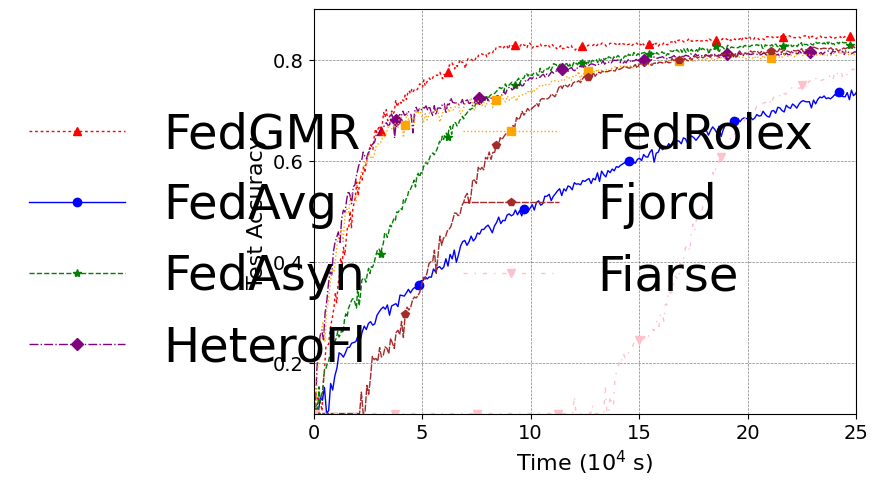

medium_iid


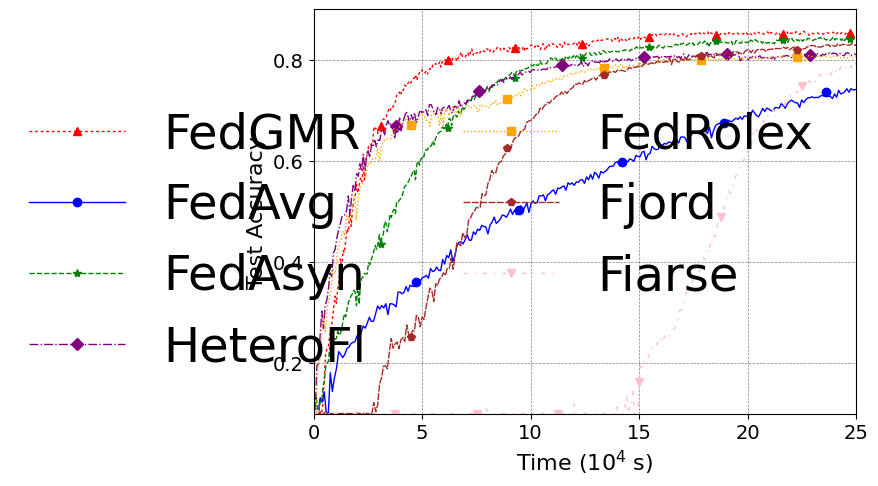

low_iid


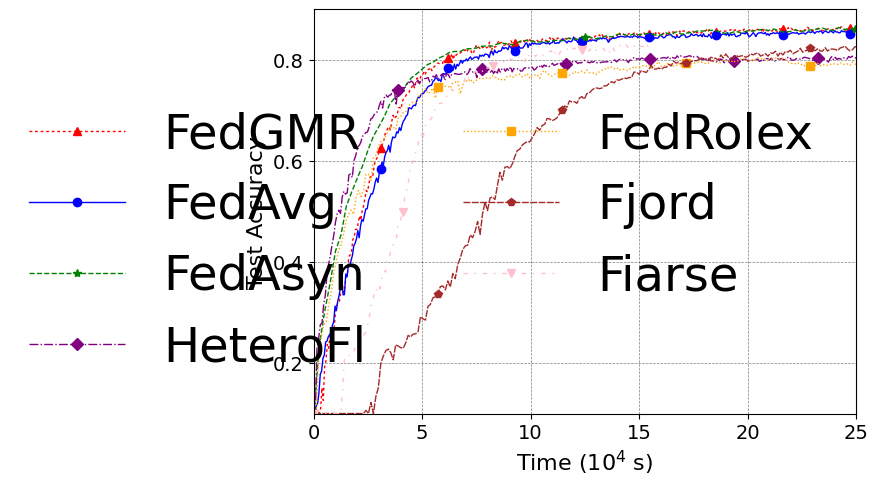

high_niid


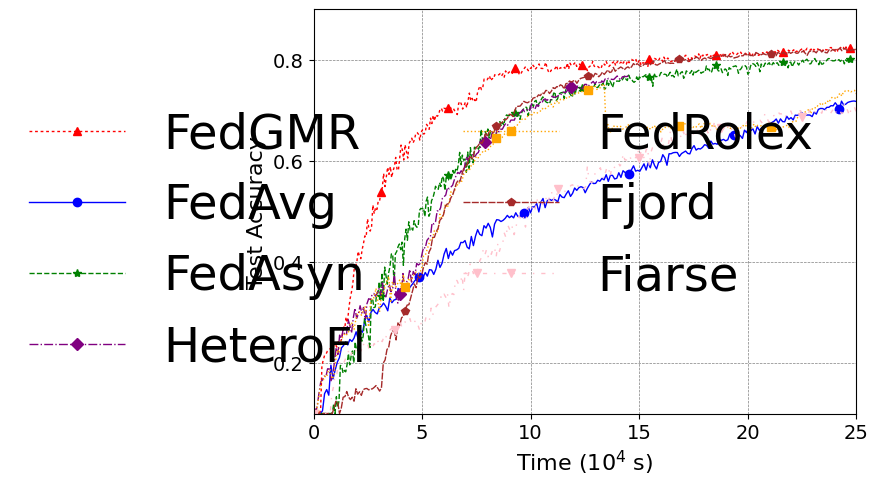

medium_niid


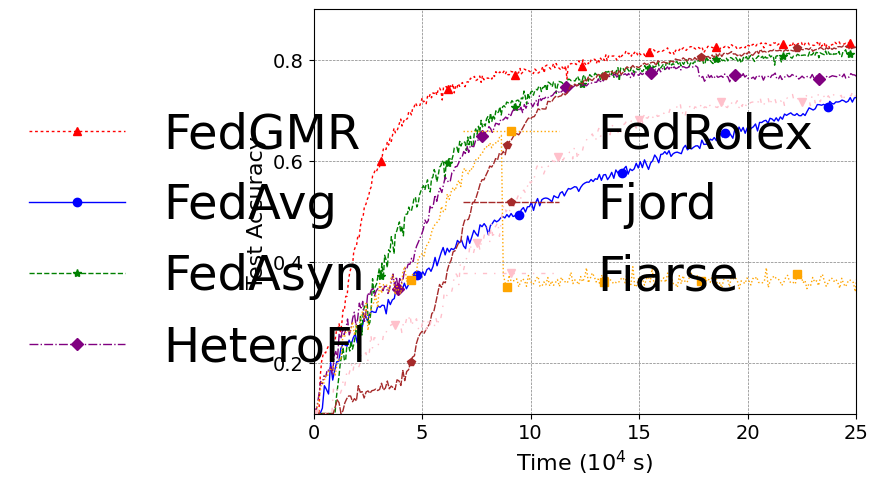

low_niid


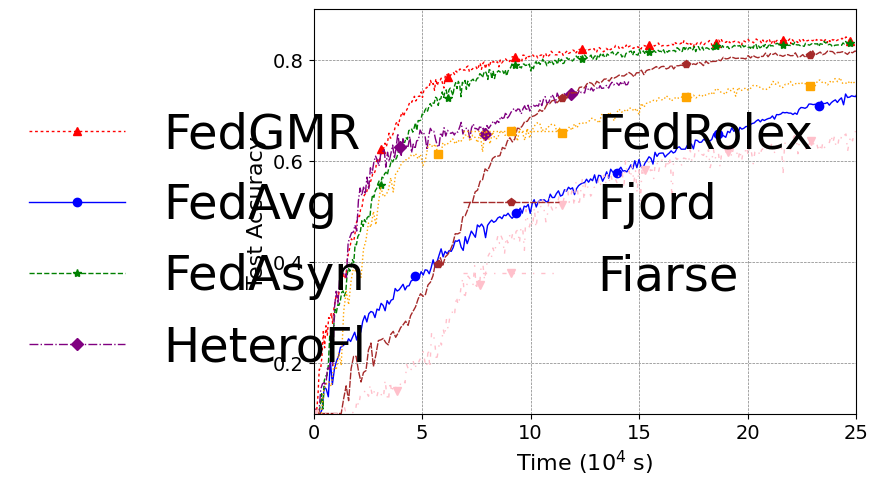

In [41]:
exp_list =[# ===== IID =====
'iid_2.0_high_pr_fl_FEMNIST_10',
 'iid_high__fed_avg_Cifar10_5_5',
 'iid_2.0_high_fed_asyn_Cifar10',
 'iid_high_heterofl_Cifar10',
'iid_high_fedrolex_Cifar10NBP',
 'iid_high_fjord_Cifar10',
 'iid_2.0_high_fiarse_FEMNIST_w',



'iid_2.0_medium_pr_fl_Cifar10_25',
 'iid_medium__fed_avg_Cifar10_5_5',
'iid_2.0_medium_fed_asyn_Cifar10',
 'iid_medium_heterofl_Cifar10',
 'iid_medium_fedrolex_Cifar10NBP',
 'iid_medium_fjord_Cifar10',
 'iid_2.0_medium_fiarse_FEMNIST_w',


'iid_2.0_low_pr_fl_FEMNIST_1', 
 'iid_2.0_low_fed_asyn_Cifar10',    
 'iid_low__fed_asyn_Cifar10_5_200_bp',
 'iid_low_heterofl_Cifar10',
 'iid_low_fedrolex_Cifar10NBP',
 'iid_low_fjord_Cifar10',
 'iid_2.0_low_fiarse_FEMNIST_w',


 'niid_2.0_high_pr_fl_FEMNIST_15',
 'niid_high__fed_avg_Cifar10_5_5',
 'niid_2.0_high_fed_asyn_Cifar10',
 'niid_high_heterofl_Cifar10',
 'niid_high_fedrolex_Cifar10NBP',
 'niid_high_fjord_Cifar10',
 'niid_2.0_high_fiarse_FEMNIST_w',


    
'niid_2.0_medium_pr_fl_Cifar10_30',
 'niid_medium__fed_avg_Cifar10_5_5',
'niid_2.0_medium_fed_asyn_Cifar10',
 'niid_medium_heterofl_Cifar10',
 'niid_medium_fedrolex_Cifar10NBP',
 'niid_medium_fjord_Cifar10',
'niid_2.0_medium_fiarse_FEMNIST_w',


 'niid_2.0_low_pr_fl_FEMNIST_1',
 'niid_low__fed_avg_Cifar10_5_5',
 'niid_2.0_low_fed_asyn_Cifar10',
 'niid_low_heterofl_Cifar10',
 'niid_low_fedrolex_Cifar10NBP',
 'niid_low_fjord_Cifar10',
 'niid_2.0_low_fiarse_FEMNIST_w',

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = [
'FedGMR',
'FedAvg',
'FedAsyn',
'HeteroFl',
'FedRolex',
'Fjord',
'Fiarse',
]

  
# plt_time_acc(exp_list, 60000)
plt_time_acc(exp_list, 220000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn +'baseline'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.10,0.90],x_lim= [0,250000])
    i= i+len(exp_legend)
    



iid_2.0_high_pr_fl_FEMNIST_10 [220000, 84.52, '0.14']
Ablation_iid_high_asyn [220000, 84.36, '0.28']
Ablation_iid_high_gmr [220000, 81.65, '0.26']
Ablation_iid_high_buff [220000, 83.98, '0.18']
Ablation_iid_high_ims [220000, 84.54, '0.22']
Ablation_iid_high_pure [220000, 84.35, '0.22']
iid_2.0_medium_pr_fl_Cifar10_25 [220000, 85.31, '0.22']
Ablation_iid_medium_asyn [220000, 85.39, '0.15']
Ablation_iid_medium_gmr [220000, 84.2, '0.21']
Ablation_iid_medium_buff [220000, 85.36, '0.12']
Ablation_iid_medium_ims [220000, 84.91, '0.15']
Ablation_iid_medium_pure [220000, 85.09, '0.2']
iid_2.0_low_pr_fl_FEMNIST_1 [220000, 85.99, '0.18']
Ablation_iid_low_asyn [220000, 65.4, '7.1']
Ablation_iid_low_gmr [220000, 84.81, '0.14']
Ablation_iid_low_buff [220000, 85.61, '0.18']
Ablation_iid_low_ims [220000, 85.65, '0.17']
Ablation_iid_low_pure [220000, 85.52, '0.17']
niid_2.0_high_pr_fl_FEMNIST_15 [220000, 81.68, '0.28']
Ablation_niid_high_asyn [220000, 80.53, '0.22']
Ablation_niid_high_gmr [220000, 71.

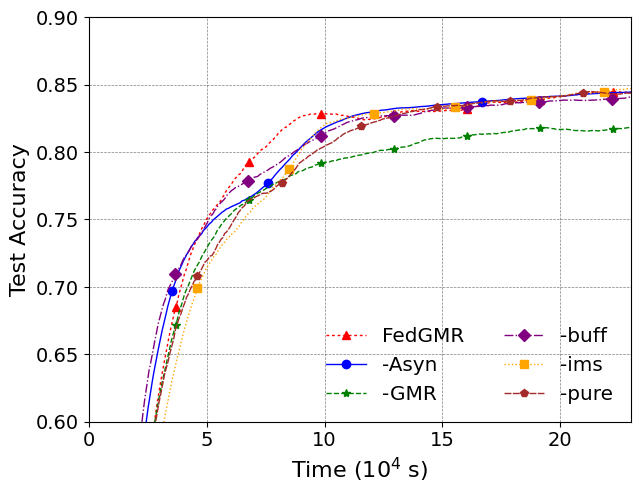

medium_iid


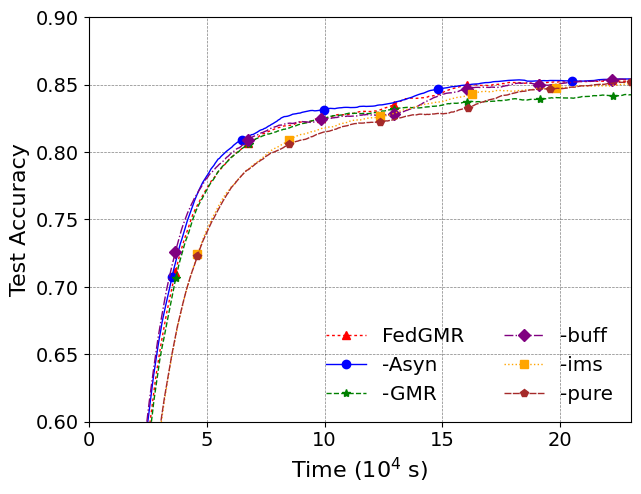

low_iid


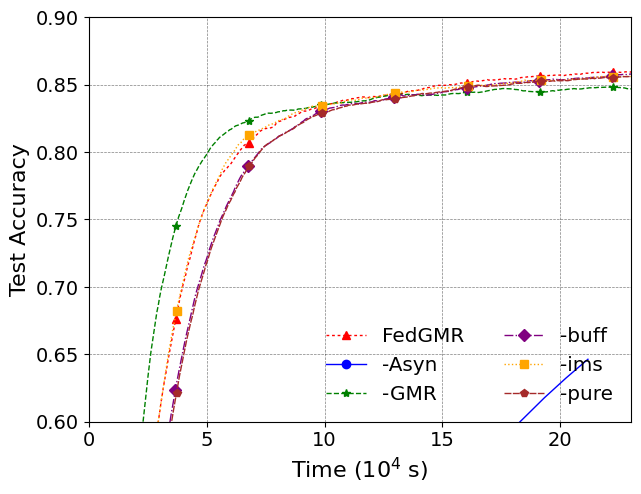

high_niid


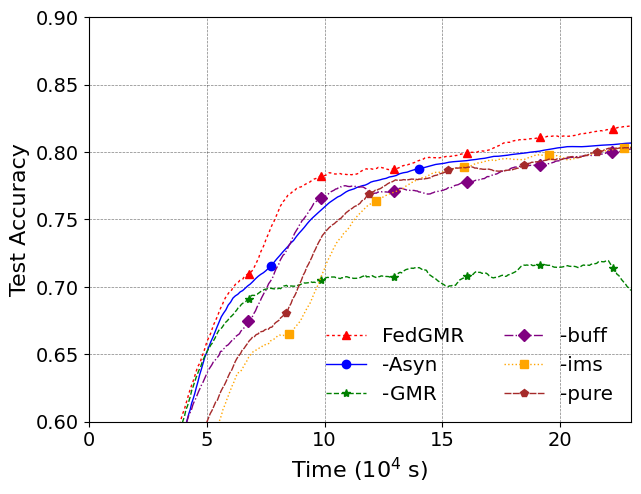

medium_niid


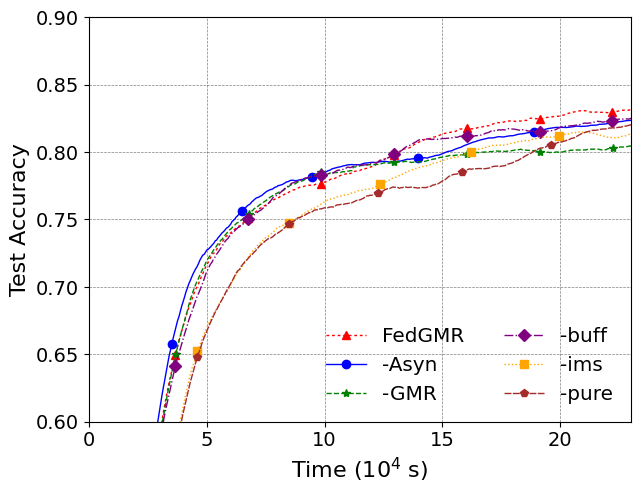

low_niid


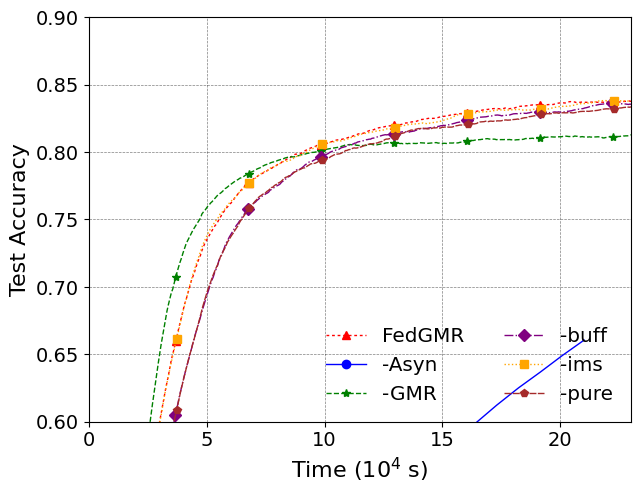

In [13]:
exp_list =[# ===== IID =====



'iid_2.0_high_pr_fl_FEMNIST_10',
'Ablation_iid_high_asyn', 
'Ablation_iid_high_gmr',
'Ablation_iid_high_buff',
'Ablation_iid_high_ims',
'Ablation_iid_high_pure',  

'iid_2.0_medium_pr_fl_Cifar10_25',
'Ablation_iid_medium_asyn', 
'Ablation_iid_medium_gmr',
'Ablation_iid_medium_buff',
'Ablation_iid_medium_ims',
'Ablation_iid_medium_pure',  

    
'iid_2.0_low_pr_fl_FEMNIST_1', 
'Ablation_iid_low_asyn', 
'Ablation_iid_low_gmr',
'Ablation_iid_low_buff',
'Ablation_iid_low_ims',
'Ablation_iid_low_pure',  

    

 'niid_2.0_high_pr_fl_FEMNIST_15',
'Ablation_niid_high_asyn', 
'Ablation_niid_high_gmr',
'Ablation_niid_high_buff',
'Ablation_niid_high_ims',
'Ablation_niid_high_pure',  
    


'niid_2.0_medium_pr_fl_Cifar10_30',
'Ablation_niid_medium_asyn', 
'Ablation_niid_medium_gmr',
'Ablation_niid_medium_buff',
'Ablation_niid_medium_ims',
'Ablation_niid_medium_pure',  

    

 'niid_2.0_low_pr_fl_FEMNIST_1',
'Ablation_niid_low_asyn', 
'Ablation_niid_low_gmr',
'Ablation_niid_low_buff',
'Ablation_niid_low_ims',
'Ablation_niid_low_pure',  

]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['FedGMR',
 '-Asyn',
 '-GMR',
 '-buff',
 '-ims',
'-pure']
# plt_time_acc(exp_list, 9000)
plt_time_acc(exp_list, 220000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'ablation'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.6,0.90],x_lim= [0,230000],cov=True)
    i= i+len(exp_legend)
    
  


iid_2.0_high_pr_fl_FEMNIST_10 [220000, 84.52, '0.14']
Ablation_iid_high_re_gradient_avg [220000, 83.73, '0.19']
Ablation_iid_high_re_mask_fed_avg [220000, 10.0, '1.4e-15']
Ablation_iid_high_gmr [220000, 81.65, '0.26']
Ablation_iid_high_gradient_avg [220000, 80.66, '0.69']
Ablation_iid_high_mask_fed_avg [220000, 10.0, '1.4e-15']
iid_2.0_medium_pr_fl_Cifar10_25 [220000, 85.31, '0.22']
Ablation_iid_medium_re_gradient_avg [220000, 83.48, '0.21']
Ablation_iid_medium_re_mask_fed_avg [220000, 10.0, '1.4e-15']
Ablation_iid_medium_gmr [220000, 84.2, '0.21']
Ablation_iid_medium_gradient_avg [220000, 82.11, '0.21']
Ablation_iid_medium_mask_fed_avg [220000, 10.0, '1.4e-15']
iid_2.0_low_pr_fl_FEMNIST_1 [220000, 85.99, '0.18']
Ablation_iid_low_re_gradient_avg [220000, 85.59, '0.21']
Ablation_iid_low_re_mask_fed_avg [220000, 10.0, '1.4e-15']
Ablation_iid_low_gmr [220000, 84.81, '0.14']
Ablation_iid_low_gradient_avg [220000, 85.2, '0.2']
Ablation_iid_low_mask_fed_avg [220000, 10.0, '1.4e-15']
niid_2.0

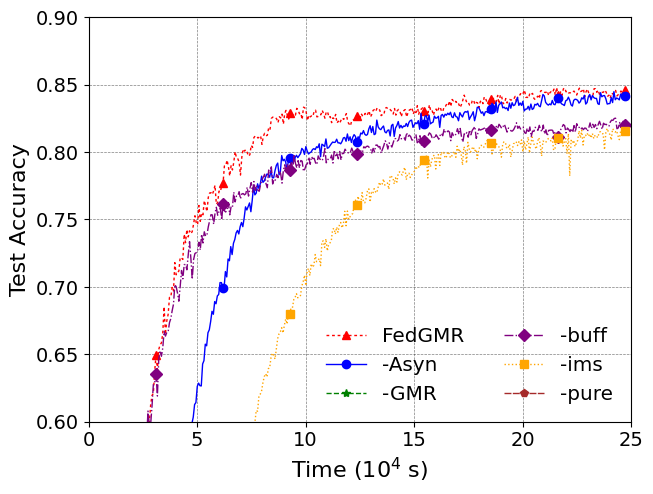

medium_iidagg


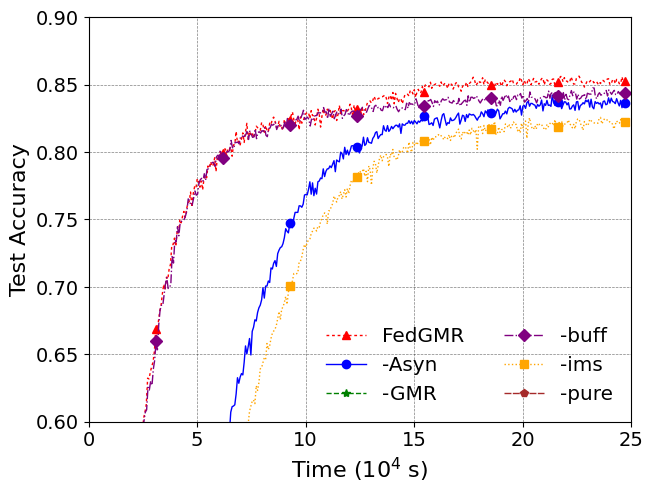

low_iidagg


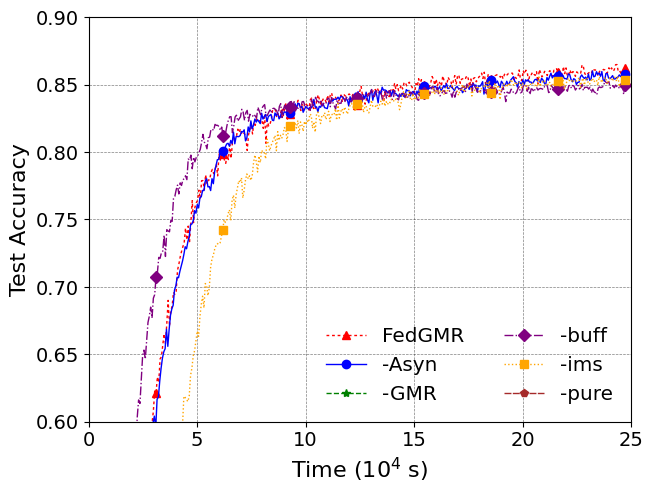

high_niidagg


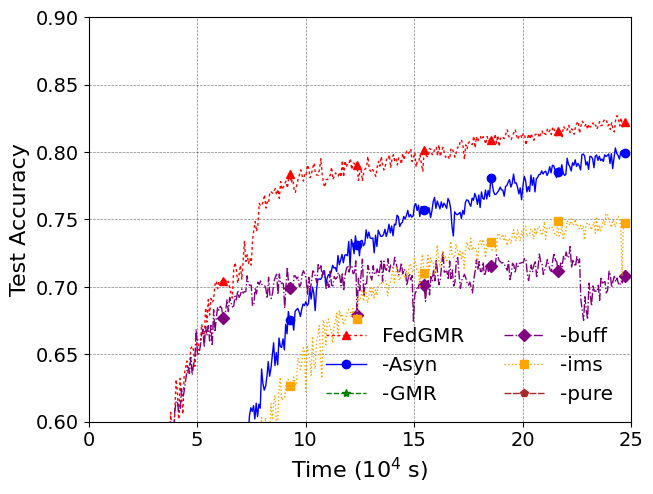

medium_niidagg


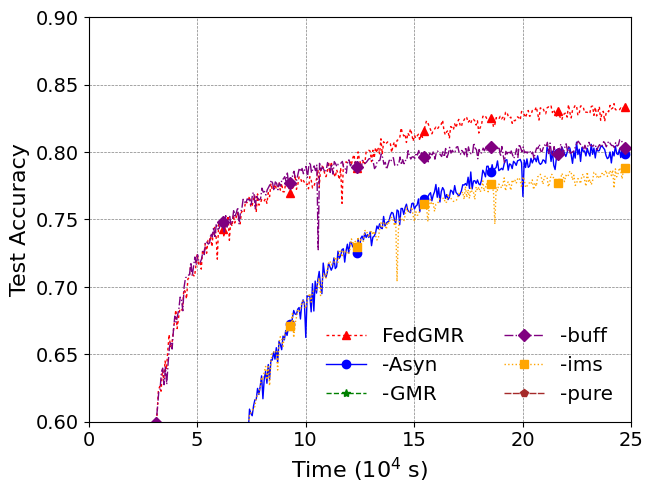

low_niidagg


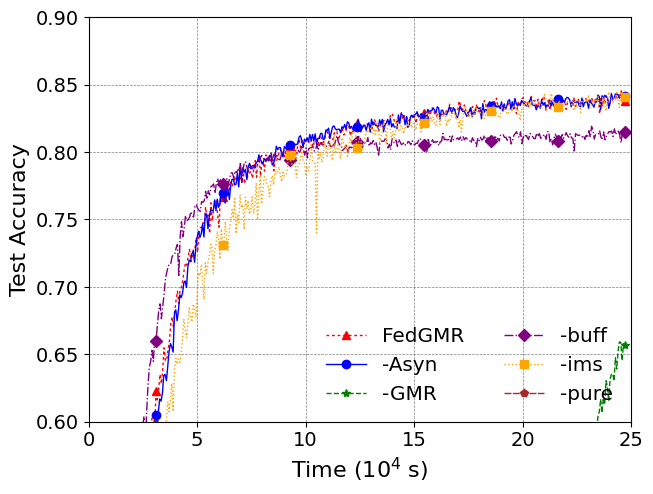

In [15]:
exp_list =[
'iid_2.0_high_pr_fl_FEMNIST_10',
'Ablation_iid_high_re_gradient_avg', 
'Ablation_iid_high_re_mask_fed_avg', 
'Ablation_iid_high_gmr',
'Ablation_iid_high_gradient_avg', 
'Ablation_iid_high_mask_fed_avg', 



'iid_2.0_medium_pr_fl_Cifar10_25',
'Ablation_iid_medium_re_gradient_avg', 
'Ablation_iid_medium_re_mask_fed_avg', 
'Ablation_iid_medium_gmr',
'Ablation_iid_medium_gradient_avg', 
'Ablation_iid_medium_mask_fed_avg', 


    
'iid_2.0_low_pr_fl_FEMNIST_1', 
 'Ablation_iid_low_re_gradient_avg', 
'Ablation_iid_low_re_mask_fed_avg', 
'Ablation_iid_low_gmr',
'Ablation_iid_low_gradient_avg', 
'Ablation_iid_low_mask_fed_avg',

    

 'niid_2.0_high_pr_fl_FEMNIST_15',
'Ablation_niid_high_re_gradient_avg', 
'Ablation_niid_high_re_mask_fed_avg', 
'Ablation_niid_high_gmr',
'Ablation_niid_high_gradient_avg', 
'Ablation_niid_high_mask_fed_avg', 
    


'niid_2.0_medium_pr_fl_Cifar10_30',
'Ablation_niid_medium_re_gradient_avg', 
'Ablation_niid_medium_re_mask_fed_avg', 
'Ablation_niid_medium_gmr',
'Ablation_niid_medium_gradient_avg', 
'Ablation_niid_medium_mask_fed_avg', 

    

 'niid_2.0_low_pr_fl_FEMNIST_1',
'Ablation_niid_low_re_gradient_avg', 
'Ablation_niid_low_re_mask_fed_avg', 
'Ablation_niid_low_gmr',
'Ablation_niid_low_gradient_avg', 
'Ablation_niid_low_mask_fed_avg', 
]


fig_name_list = ['high_iidagg','medium_iidagg','low_iidagg','high_niidagg','medium_niidagg','low_niidagg',]
exp_legend = exp_legend = ['FedGMR',
 '-Asyn',
 '-GMR',
 '-buff',
 '-ims',
'-pure']


# plt_time_acc(exp_list, 7000)
plt_time_acc(exp_list, 220000)
# plt_time_acc(exp_list, 250000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,250000])
    i= i+len(exp_legend)






Skipping iid_2.0_high_pr_fl_Cifar10_50. Client selection = False.
Ablation_iid_high_gmr [200000, 81.68, '0.23']
iid_high__fed_asyn_Cifar10_5_200_bp [200000, 83.65, '0.33']
iid_2.0_high_pr_fl_FEMNIST_1 [200000, 83.79, '0.27']
iid_2.0_high_pr_fl_FEMNIST_3 [200000, 84.09, '0.3']
iid_2.0_high_pr_fl_FEMNIST [200000, 83.53, '0.26']
iid_2.0_high_pr_fl_FEMNIST_7 [200000, 83.66, '0.22']
iid_2.0_high_pr_fl_FEMNIST_10 [200000, 84.16, '0.21']
iid_2.0_high_pr_fl_FEMNIST_15 [200000, 84.32, '0.18']
iid_2.0_high_pr_fl_Cifar10_20 [200000, 84.31, '0.14']
iid_2.0_high_pr_fl_Cifar10_25 [200000, 84.18, '0.17']
iid_2.0_high_pr_fl_Cifar10_30 [200000, 83.93, '0.23']
iid_2.0_high_pr_fl_Cifar10_40 [200000, 83.18, '0.26']
Ablation_iid_medium_gmr [200000, 84.02, '0.2']
iid_medium__fed_asyn_Cifar10_5_200_bp [200000, 84.45, '0.36']
iid_2.0_medium_pr_fl_FEMNIST_1 [200000, 84.32, '0.18']
iid_2.0_medium_pr_fl_FEMNIST_3 [200000, 84.76, '0.18']
iid_2.0_medium_pr_fl_FEMNIST [200000, 84.41, '0.2']
iid_2.0_medium_pr_fl_FEM

IndexError: list index out of range

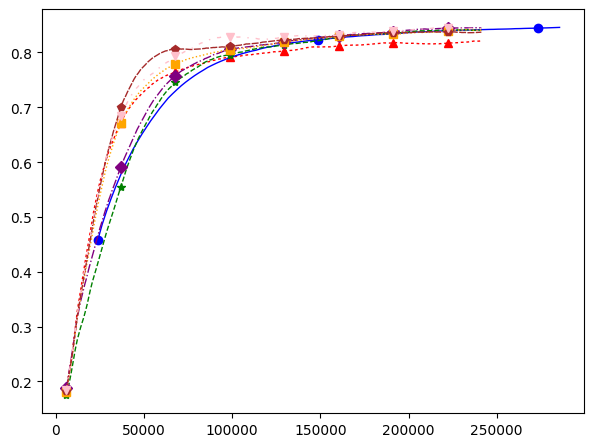

In [6]:
exp_list =[# ===== IID =====
# IID 2.0 - High
'Ablation_iid_high_gmr',
'iid_high__fed_asyn_Cifar10_5_200_bp',
'iid_2.0_high_pr_fl_FEMNIST_1',
'iid_2.0_high_pr_fl_FEMNIST_3',
'iid_2.0_high_pr_fl_FEMNIST',     # 代表 5
'iid_2.0_high_pr_fl_FEMNIST_7',
'iid_2.0_high_pr_fl_FEMNIST_10',
'iid_2.0_high_pr_fl_FEMNIST_15',
'iid_2.0_high_pr_fl_Cifar10_20',
'iid_2.0_high_pr_fl_Cifar10_25',
'iid_2.0_high_pr_fl_Cifar10_30',
'iid_2.0_high_pr_fl_Cifar10_40',
'iid_2.0_high_pr_fl_Cifar10_50',
# IID 2.0 - Medium
'Ablation_iid_medium_gmr',
 'iid_medium__fed_asyn_Cifar10_5_200_bp',
'iid_2.0_medium_pr_fl_FEMNIST_1',
'iid_2.0_medium_pr_fl_FEMNIST_3',
'iid_2.0_medium_pr_fl_FEMNIST',   # 代表 5
'iid_2.0_medium_pr_fl_FEMNIST_7',
'iid_2.0_medium_pr_fl_FEMNIST_10',
'iid_2.0_medium_pr_fl_FEMNIST_15',
'iid_2.0_medium_pr_fl_Cifar10_20',
'iid_2.0_medium_pr_fl_Cifar10_25',
'iid_2.0_medium_pr_fl_Cifar10_30',
'iid_2.0_medium_pr_fl_Cifar10_40',
'iid_2.0_medium_pr_fl_Cifar10_50',
# IID 2.0 - Low
'Ablation_iid_low_gmr',
 'iid_low__fed_asyn_Cifar10_5_200_bp',
'iid_2.0_low_pr_fl_FEMNIST_1',
'iid_2.0_low_pr_fl_FEMNIST_3',
'iid_2.0_low_pr_fl_FEMNIST',      # 代表 5
'iid_2.0_low_pr_fl_FEMNIST_7',
'iid_2.0_low_pr_fl_FEMNIST_10',
'iid_2.0_low_pr_fl_FEMNIST_15',
'iid_2.0_low_pr_fl_Cifar10_20',
'iid_2.0_low_pr_fl_Cifar10_25',
'iid_2.0_low_pr_fl_Cifar10_30',
'iid_2.0_low_pr_fl_Cifar10_40',
'iid_2.0_low_pr_fl_Cifar10_50',
# Non-IID 2.0 - High
'Ablation_niid_high_gmr',
 'niid_high__fed_asyn_Cifar10_5_200_bp',
'niid_2.0_high_pr_fl_FEMNIST_1',
'niid_2.0_high_pr_fl_FEMNIST_3',
'niid_2.0_high_pr_fl_FEMNIST',    # 代表 5
'niid_2.0_high_pr_fl_FEMNIST_7',
'niid_2.0_high_pr_fl_FEMNIST_10',
'niid_2.0_high_pr_fl_FEMNIST_15',
'niid_2.0_high_pr_fl_Cifar10_20',
'niid_2.0_high_pr_fl_Cifar10_25',
'niid_2.0_high_pr_fl_Cifar10_30',
'niid_2.0_high_pr_fl_Cifar10_40',
'niid_2.0_high_pr_fl_Cifar10_50',
    
# Non-IID 2.0 - Medium
'Ablation_niid_medium_gmr',
 'niid_medium__fed_asyn_Cifar10_5_200_bp',
'niid_2.0_medium_pr_fl_FEMNIST_1',
'niid_2.0_medium_pr_fl_FEMNIST_3',
'niid_2.0_medium_pr_fl_FEMNIST',  # 代表 5
'niid_2.0_medium_pr_fl_FEMNIST_7',
'niid_2.0_medium_pr_fl_FEMNIST_10',
'niid_2.0_medium_pr_fl_FEMNIST_15',
'niid_2.0_medium_pr_fl_Cifar10_20',
'niid_2.0_medium_pr_fl_Cifar10_25',
'niid_2.0_medium_pr_fl_Cifar10_30',
'niid_2.0_medium_pr_fl_Cifar10_40',
'niid_2.0_medium_pr_fl_Cifar10_50',
    
# Non-IID 2.0 - Low
'Ablation_niid_low_gmr',
 'niid_low__fed_asyn_Cifar10_5_200_bp',
'niid_2.0_low_pr_fl_FEMNIST_1',
'niid_2.0_low_pr_fl_FEMNIST_3',
'niid_2.0_low_pr_fl_FEMNIST',     # 代表 5
'niid_2.0_low_pr_fl_FEMNIST_7',
'niid_2.0_low_pr_fl_FEMNIST_10',
'niid_2.0_low_pr_fl_FEMNIST_15',
'niid_2.0_low_pr_fl_Cifar10_20',
'niid_2.0_low_pr_fl_Cifar10_25',
'niid_2.0_low_pr_fl_Cifar10_30',
'niid_2.0_low_pr_fl_Cifar10_40',
'niid_2.0_low_pr_fl_Cifar10_50',
    
]

fig_name_list = ['high_iid','medium_iid','low_iid','high_niid','medium_niid','low_niid',]
exp_legend = ['GMR','P=1','P=3','P=5',
              'P=7','P=10',
              'P=15','P=20','P=25',
              'P=30', 'P=40','P=50',]

  
# plt_time_acc(exp_list, 150000)
plt_time_acc(exp_list, 200000)
plt_time_acc(exp_list, 220000)
i = 0 
while i < len(exp_list):
    exp = exp_list[i:i+len(exp_legend)]
    fn = fig_name_list[int(i/len(exp_legend))]
    print(fn)
    fn = fn+'patience'
    plt_photo_acc(exp,exp_legend,fig_name = fn,y_lim= [0.60,0.90],x_lim= [0,280000],cov = True)
    i= i+len(exp_legend)
    

